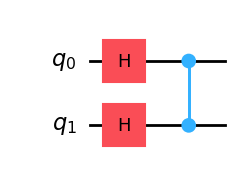

In [15]:
from qiskit import QuantumCircuit
from disqco import QuantumCircuitHyperGraph, QuantumNetwork, set_initial_partition_assignment

circuit = QuantumCircuit(2)
for i in range(2):
    circuit.h(i)
circuit.cz(0, 1)
# circuit.cz(0, 2)
# circuit.cz(0, 3)
# circuit.cx(0, 4)
# circuit.cx(0, 5)

circuit.draw('mpl')



Initial partition assignment: [[0 1]
 [1 1]]
DistributedCircuit (2q, 4p):
  LocalGate: 3
  StateTransfer: 1
DistributedCircuitToQiskit depth : 5

High-level instruction blocks:
  FanIn[q0:p0→p1]                               x1
  FanOut[q0:p0→[1]]                             x1
  cz                                            x1
  h                                             x2
  measure                                       x2
  reset                                         x1


/Users/ftb123/anaconda3/envs/disqco_env/lib/python3.13/site-packages/qiskit/circuit/quantumcircuit.py:3394: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


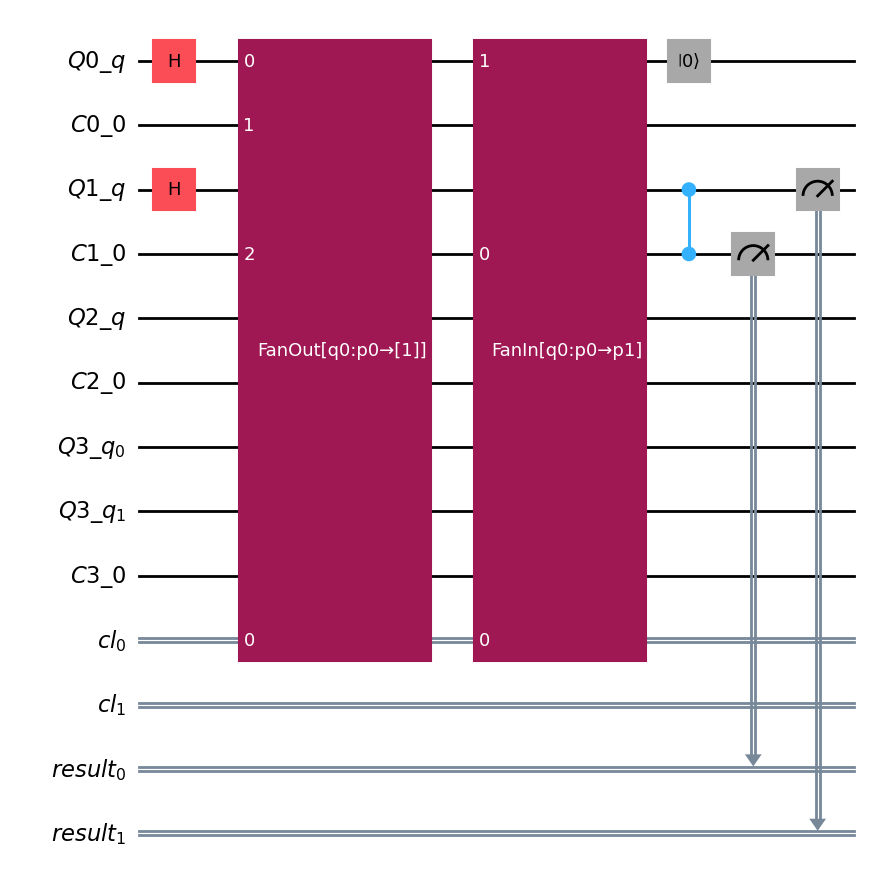

In [16]:
graph = QuantumCircuitHyperGraph(circuit=circuit, group_gates=True, anti_diag=True)

network = QuantumNetwork([1,1,1,2],qpu_connectivity=[(0,1), (1,2), (2,3)])

assignment = set_initial_partition_assignment(graph=graph, network=network)
for i in range(1,len(assignment[0])):   
    assignment[i][0] = 1

print("Initial partition assignment:", assignment)

from disqco.circuit_extraction import HypergraphToDistributed

builder = HypergraphToDistributed(graph, network, assignment)

dc = builder.build()
print(dc.summary())

from disqco.drawing import DistributedCircuitQPIC

renderer = DistributedCircuitQPIC(dc, draw_qpu_boundaries=True)
qpic_str = renderer.to_qpic_string()
with open("fanout_test.qpic", "w") as f:
    f.write(qpic_str)

from disqco.circuit_extraction import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, network, assignment[0])
dc_qiskit = lowerer.build()

print(f"DistributedCircuitToQiskit depth : {dc_qiskit.depth()}")
print()
print("High-level instruction blocks:")
for name, count in sorted(dc_qiskit.count_ops().items()):
    print(f"  {name:45s} x{count}")

dc_qiskit.draw('mpl', fold=100)

DistributedCircuitToQiskit depth : 5

High-level instruction blocks:
  FanIn[q0:p0→p1]                               x1
  FanOut[q0:p0→[1]]                             x1
  cz                                            x1
  h                                             x2
  measure                                       x2
  reset                                         x1


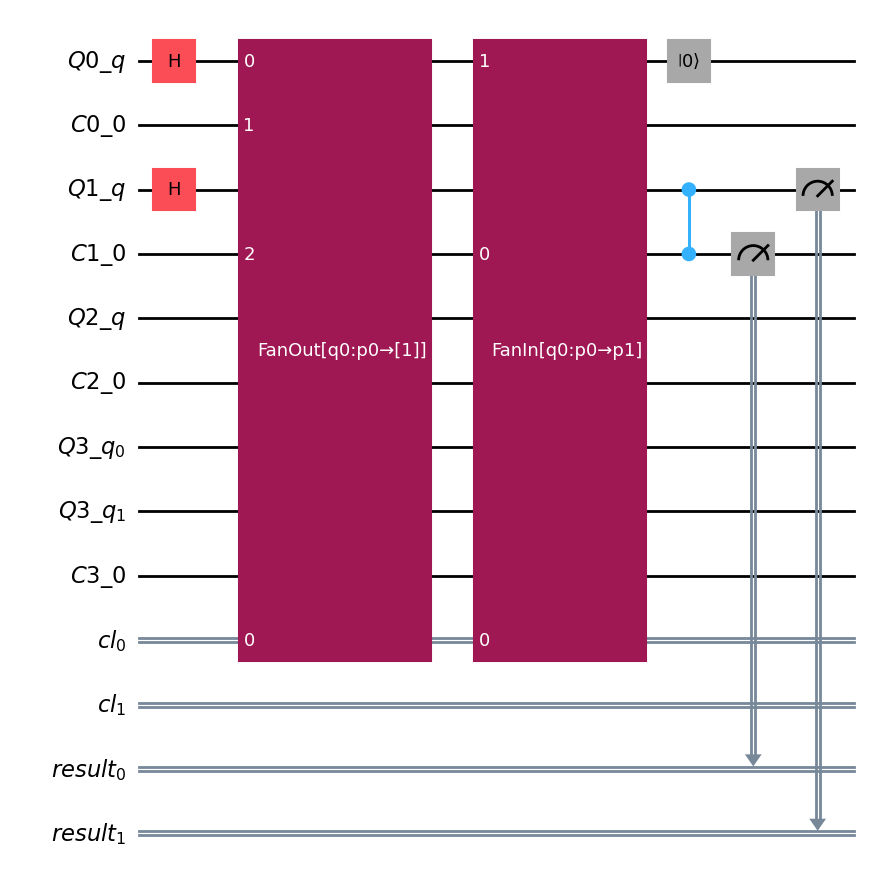

In [17]:
renderer = DistributedCircuitQPIC(dc)
qpic_str = renderer.to_qpic_string_lowered()
with open("fanout_test_lowered.qpic", "w") as f:
    f.write(qpic_str)

from disqco.circuit_extraction import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, network, assignment[0])
dc_qiskit = lowerer.build()

print(f"DistributedCircuitToQiskit depth : {dc_qiskit.depth()}")
print()
print("High-level instruction blocks:")
for name, count in sorted(dc_qiskit.count_ops().items()):
    print(f"  {name:45s} x{count}")

dc_qiskit.draw('mpl', fold=100)

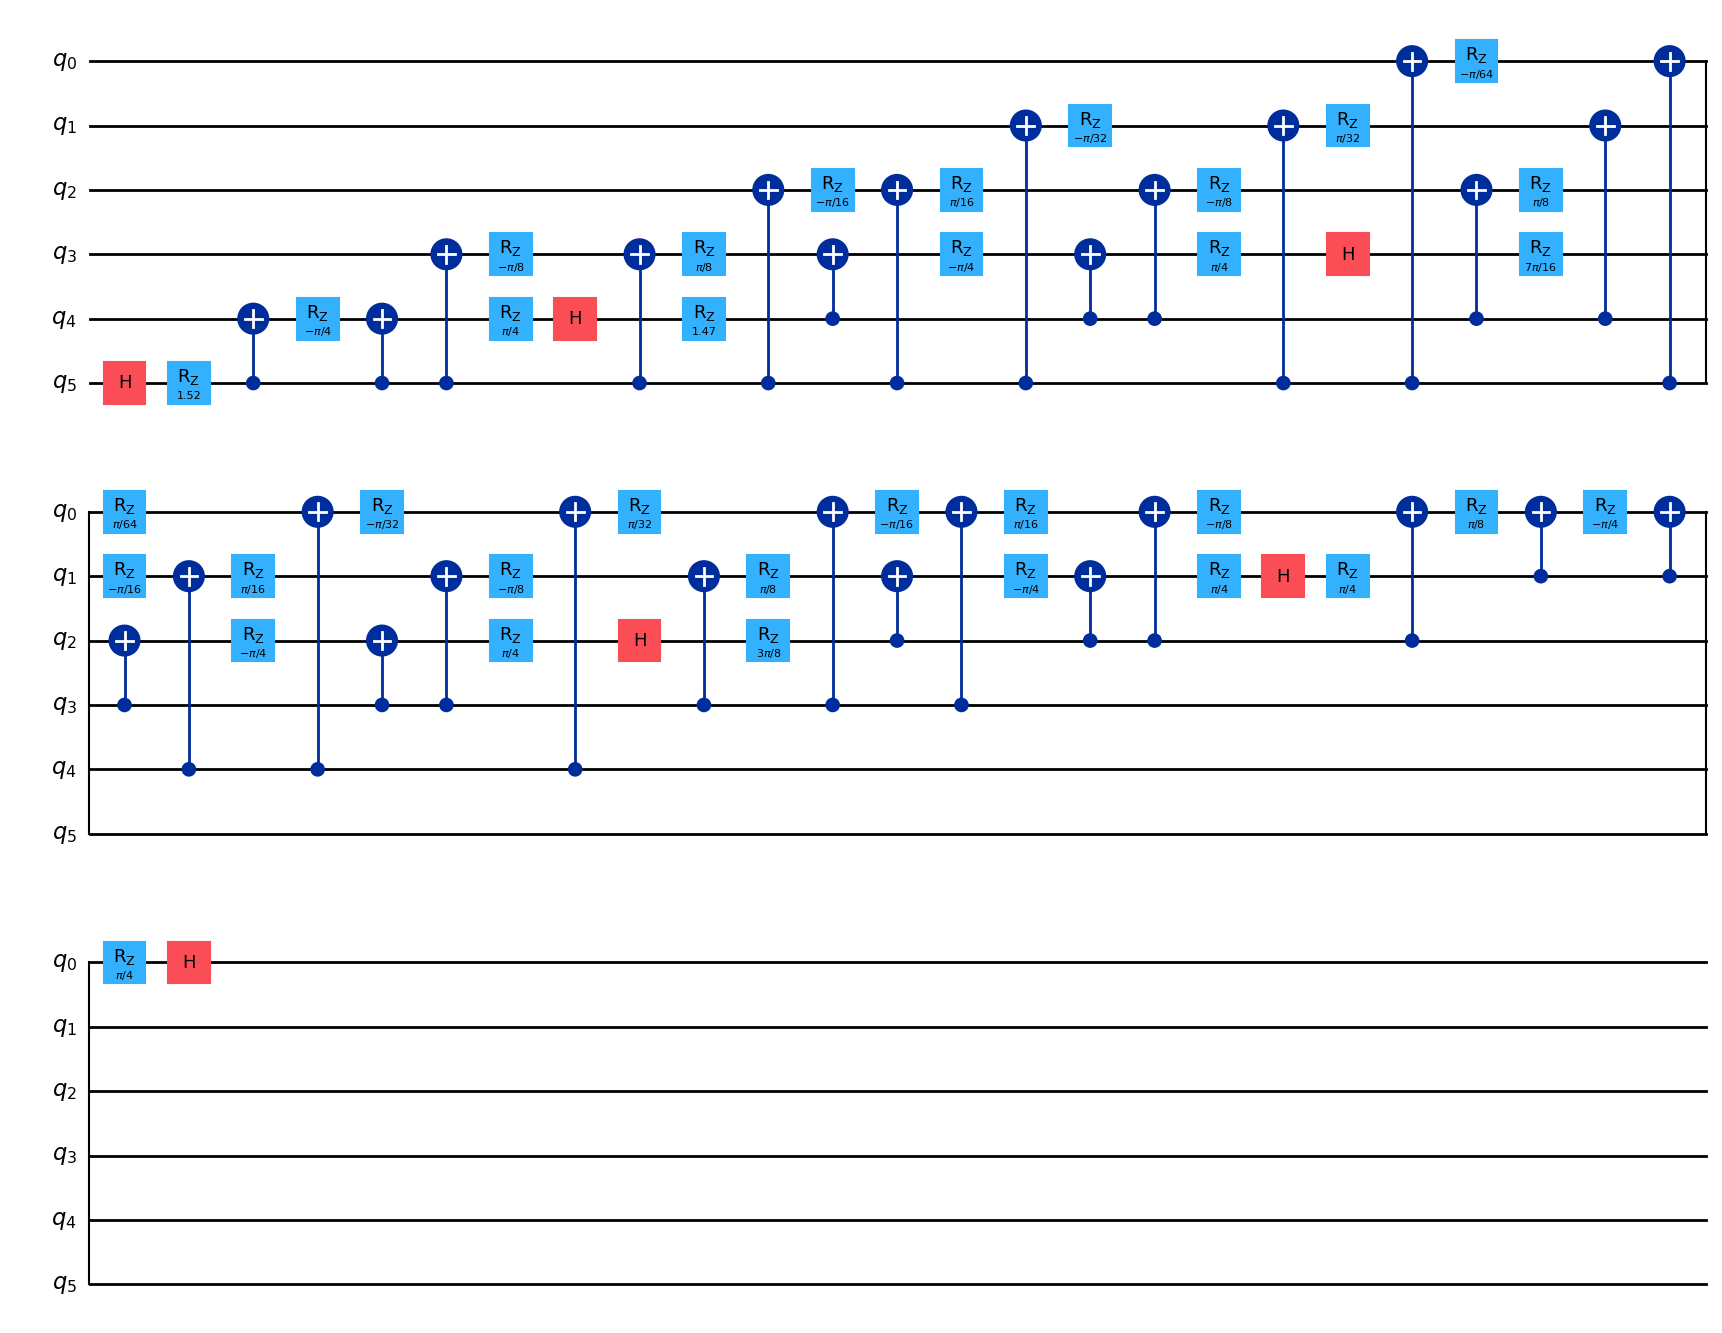

In [18]:
from qiskit import transpile
from qiskit.circuit.library import QFT

circuit = QFT(6, do_swaps=False)
    
circuit = transpile(circuit, basis_gates=['cx', 'rz', 'h'], optimization_level=3)

circuit.draw('mpl')

DistributedCircuit (6q, 3p):
  FanIn: 6
  FanOut: 4
  LinkedGate: 30
  LocalGate: 41
DistributedCircuitToQiskit depth : 39

High-level instruction blocks:
  FanIn[q2:p0→p1]                               x1
  FanIn[q3:p0→p1]                               x1
  FanIn[q4:p0→p2]                               x1
  FanIn[q4:p1→p2]                               x1
  FanIn[q5:p0→p2]                               x1
  FanIn[q5:p1→p2]                               x1
  FanOut[q2:p1→[0]]                             x1
  FanOut[q3:p1→[0]]                             x1
  FanOut[q4:p2→[0, 1]]                          x1
  FanOut[q5:p2→[0, 1]]                          x1
  cx                                            x30
  h                                             x6
  measure                                       x6
  rz                                            x35


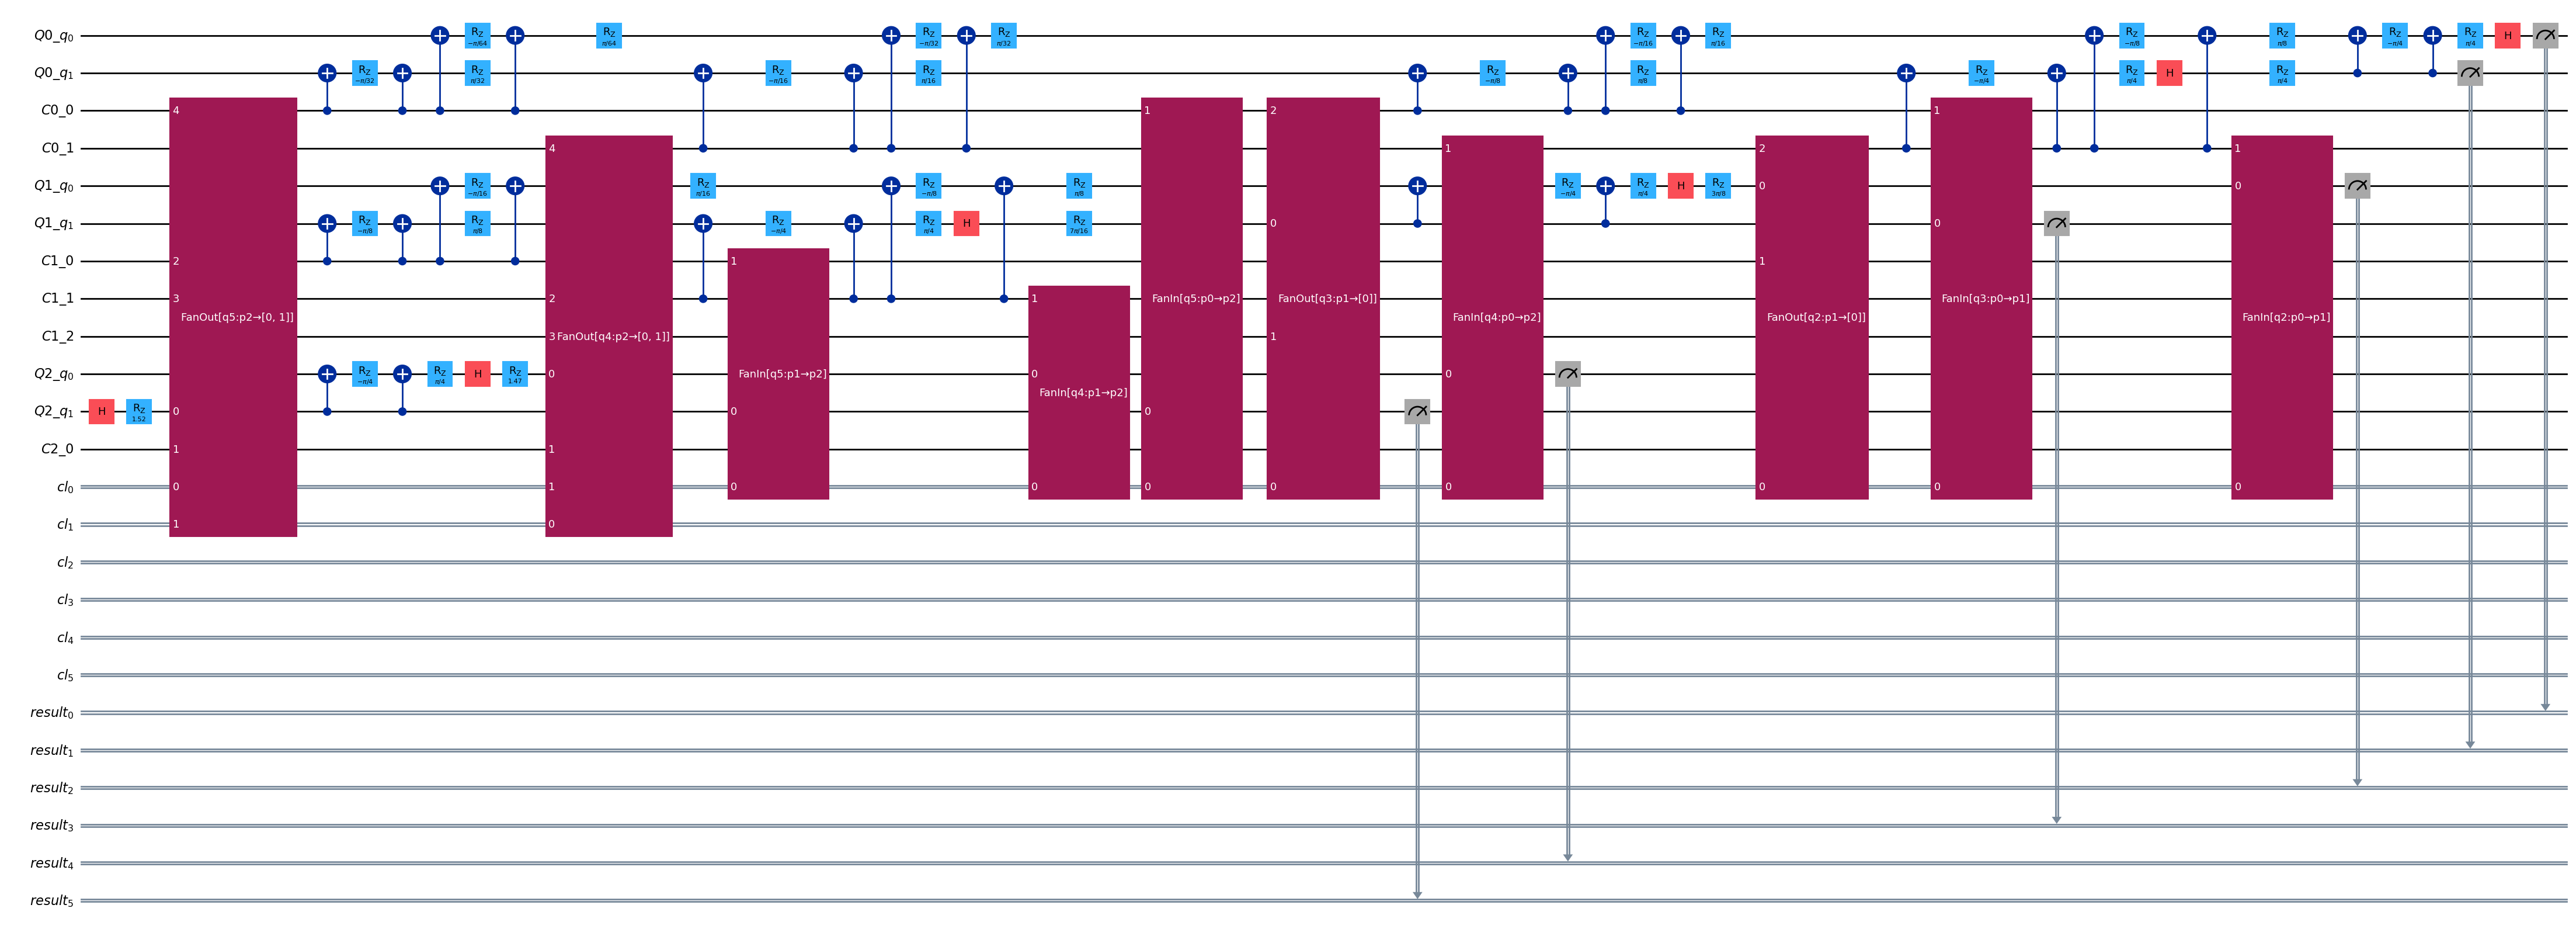

In [19]:


graph = QuantumCircuitHyperGraph(circuit=circuit, group_gates=True, anti_diag=True)
network = QuantumNetwork([2,2,2],qpu_connectivity=[(0,1), (1,2)])
assignment = set_initial_partition_assignment(graph=graph, network=network)

from disqco.circuit_extraction import HypergraphToDistributed
builder = HypergraphToDistributed(graph, network, assignment)
dc = builder.build()

print(dc.summary())

from disqco.drawing import DistributedCircuitQPIC

renderer = DistributedCircuitQPIC(dc, draw_qpu_boundaries=True, qpu_boundary_fills=['red','teal'])
qpic_str = renderer.to_qpic_string()
with open("fanout_test_qft.qpic", "w") as f:
    f.write(qpic_str)

from disqco.circuit_extraction import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, network, assignment[0])
dc_qiskit = lowerer.build()

print(f"DistributedCircuitToQiskit depth : {dc_qiskit.depth()}")
print()
print("High-level instruction blocks:")
for name, count in sorted(dc_qiskit.count_ops().items()):
    print(f"  {name:45s} x{count}")

dc_qiskit.draw('mpl', fold=100)

In [20]:
renderer = DistributedCircuitQPIC(dc, draw_qpu_boundaries=True, qpu_boundary_fills=['red','teal'])
qpic_str = renderer.to_qpic_string_lowered()
with open("qft_fanout_test_qft_lowered.qpic", "w") as f:
    f.write(qpic_str)
